Student Performance Prediction

In [1]:
#importing Library for data loading

import pandas as pd

In [26]:
#Loading Data

pd.read_csv('StudentsPerformance.csv')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
# Storing data in Variable name df

df = pd.read_csv('StudentsPerformance.csv')

In [4]:
#checking the loaded data by 1 row

df.head(1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74


In [5]:
# Checking for a missing or nun Value

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
# Creating a Avg Score column

df['Avg_Score'] = df[['math score','reading score','writing score']].mean(axis = 1)

In [7]:
# Rounding off the Avg Score

df['Avg_Score'] = df['Avg_Score'].round(2)

In [8]:
#Checking the result

df.head(1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Avg_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67


Exploratory Data Analysis (EDA)

In [9]:
#Importing visualizatiom library

import seaborn as sns
import matplotlib.pyplot as plt

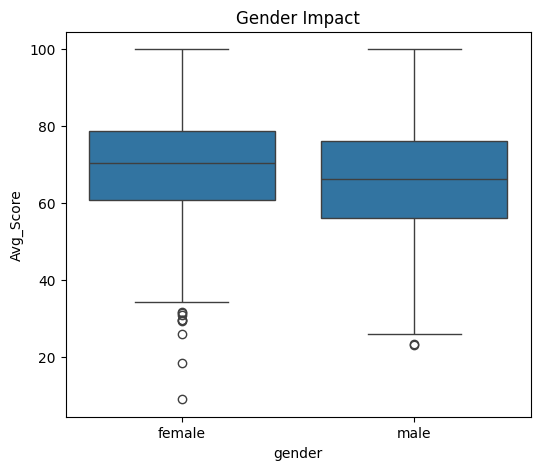

In [10]:
# Gender Impact 

plt.figure (figsize= (6,5))
sns.boxplot(data = df,x = 'gender', y = 'Avg_Score' )
plt.title('Gender Impact')
plt.show()

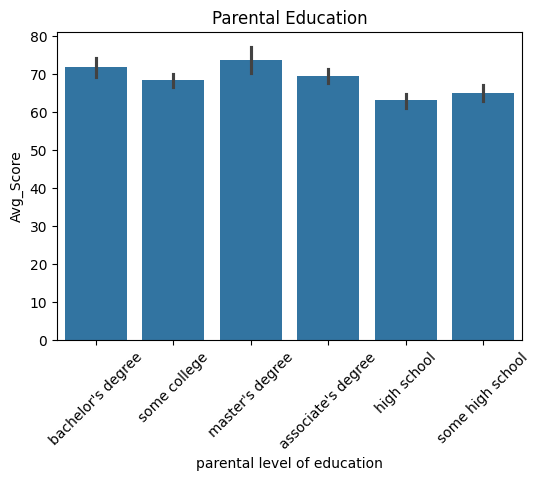

In [11]:
#Parental Education

plt.figure(figsize = (6,4))
sns.barplot(data = df , x ='parental level of education', y = 'Avg_Score' )
plt.xticks(rotation = 45)
plt.title('Parental Education')
plt.show()

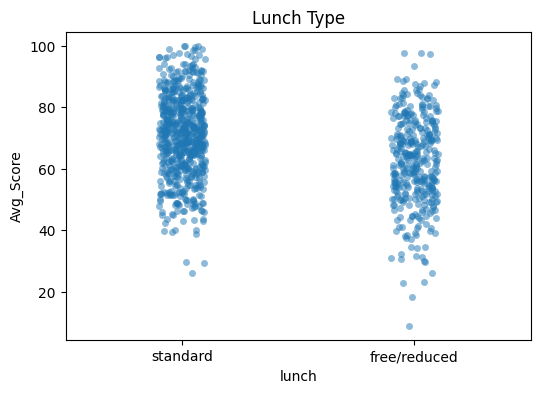

In [12]:
#Lunch Type 

plt.figure(figsize = (6,4))
sns.stripplot(data = df , x = 'lunch' , y = 'Avg_Score', alpha = 0.5 )
plt.title('Lunch Type')
plt.show()

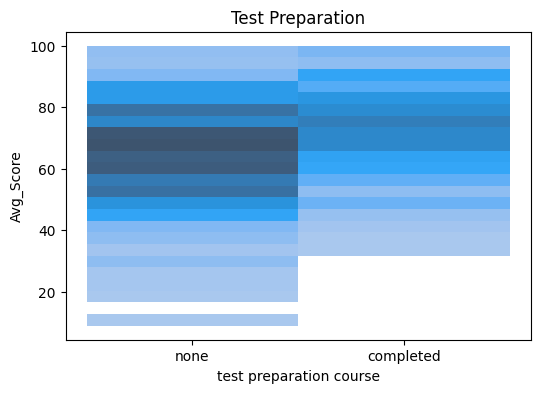

In [13]:
#Test Preparation

plt.figure(figsize=(6,4))
sns.histplot(x="test preparation course", y="Avg_Score", data=df)
plt.title("Test Preparation")
plt.show()

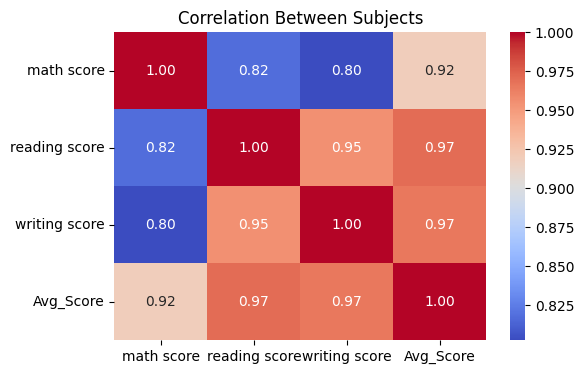

In [14]:
#Correlation Heatmap Between Subjects

corr = df[["math score", "reading score", "writing score", "Avg_Score"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Subjects")
plt.show()

In [15]:
#Converting categories data to Numbers for Machine Learning

df1 = pd.get_dummies(df,drop_first = True)

In [16]:
#Checking the result

df1.sum()

math score                                       66089.00
reading score                                    69169.00
writing score                                    68054.00
Avg_Score                                        67770.58
gender_male                                        482.00
race/ethnicity_group B                             190.00
race/ethnicity_group C                             319.00
race/ethnicity_group D                             262.00
race/ethnicity_group E                             140.00
parental level of education_bachelor's degree      118.00
parental level of education_high school            196.00
parental level of education_master's degree         59.00
parental level of education_some college           226.00
parental level of education_some high school       179.00
lunch_standard                                     645.00
test preparation course_none                       642.00
dtype: float64

Preparing and Training Models 

In [17]:
#importing train_test_split library 

from sklearn.model_selection import train_test_split

In [18]:
#Defining Target
#Using only necessary data and dropping unneccessar columns

X = df1.drop(['math score','reading score','writing score','Avg_Score'], axis = 1)
Y = df1['Avg_Score']

In [19]:
#Deploying train test split

X_train , X_test , Y_train , Y_test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)

In [20]:
# Linear Regression

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

In [21]:
#Decision Tree

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state = 42)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

In [28]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [29]:
#Function for Evaluation

import numpy as np

def evaluate_model(Y_true, Y_predict, model_name):
    mae = mean_absolute_error(Y_true, Y_predict)
    rmse = np.sqrt(mean_squared_error(Y_true, Y_predict))
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f} , ")

In [24]:
# importing library for model evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
#Model Evaluation

evaluate_model(Y_test, Y_pred_lr, "Linear Regression")
evaluate_model(Y_test, Y_pred_rf, "Random Forest")
evaluate_model(Y_test, Y_pred_dt, "Decision Tree")

Linear Regression -> MAE: 10.49, RMSE: 13.40 , 
Random Forest -> MAE: 11.48, RMSE: 14.78 , 
Decision Tree -> MAE: 11.88, RMSE: 15.25 , 
